In [ ]:
import nltk

# تحميل الملفات اللي الجهاز بيشتكي منها
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab') # زيادة تأكيد لبعض النسخ الجديدة
nltk.download('get_pos')
nltk.download('averaged_perceptron_tagger_eng')
print("NLTK Resources Downloaded!")

NLTK Resources Downloaded!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Error loading get_pos: Package 'get_pos' not found in
[nltk_data]     index
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [11]:

!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta 

In [12]:
import pandas as pd
import numpy as np
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

nlp = spacy.load("en_core_web_sm")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


In [13]:
df = pd.read_csv(r"D:\DEPI R4 AI\Data Sets\spam_or_not_spam.csv")
df['email'] = df['email'].fillna('')
df.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [14]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_process(text):
    tokens = word_tokenize(text.lower())
    
    cleaned = [stemmer.stem(w) for w in tokens if w not in stop_words and w.isalnum()]
    return " ".join(cleaned)

df['cleaned_text'] = df['email'].apply(clean_process)
print("Cleaning and Stemming completed.")

Cleaning and Stemming completed.


In [15]:
def get_pos(text):
    tokens = word_tokenize(text)
    return nltk.pos_tag(tokens)

df['pos_tags'] = df['email'].apply(get_pos) 
print("POS Tagging sample for rows:")
print(df['pos_tags'].iloc[0])

POS Tagging sample for rows:
[('date', 'NN'), ('wed', 'VBD'), ('NUMBER', 'NNP'), ('aug', 'JJ'), ('NUMBER', 'NNP'), ('NUMBER', 'NNP'), ('NUMBER', 'NNP'), ('NUMBER', 'NNP'), ('NUMBER', 'NNP'), ('from', 'IN'), ('chris', 'JJ'), ('garrigues', 'NNS'), ('cwg', 'VBP'), ('dated', 'JJ'), ('NUMBER', 'NNP'), ('NUMBERfaNUMBERd', 'NNP'), ('deepeddy', 'NNP'), ('com', 'NN'), ('message', 'NN'), ('id', 'JJ'), ('NUMBER', 'NNP'), ('NUMBER', 'NNP'), ('tmda', 'JJ'), ('deepeddy', 'JJ'), ('vircio', 'NN'), ('com', 'NN'), ('i', 'NN'), ('can', 'MD'), ('t', 'VB'), ('reproduce', 'VB'), ('this', 'DT'), ('error', 'NN'), ('for', 'IN'), ('me', 'PRP'), ('it', 'PRP'), ('is', 'VBZ'), ('very', 'RB'), ('repeatable', 'JJ'), ('like', 'IN'), ('every', 'DT'), ('time', 'NN'), ('without', 'IN'), ('fail', 'NN'), ('this', 'DT'), ('is', 'VBZ'), ('the', 'DT'), ('debug', 'JJ'), ('log', 'NN'), ('of', 'IN'), ('the', 'DT'), ('pick', 'NN'), ('happening', 'VBG'), ('NUMBER', 'NNP'), ('NUMBER', 'NNP'), ('NUMBER', 'NNP'), ('pick_it', 'JJ'), 

In [16]:
def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]


entities = extract_entities(df['email'].iloc[0])
print("Named Entities found in the first email:")
print(entities)

Named Entities found in the first email:
[('chris garrigues cwg', 'PERSON'), ('kre ps', 'PERSON'), ('a day ago', 'DATE'), ('today', 'DATE')]


Note: you may need to restart the kernel to use updated packages.


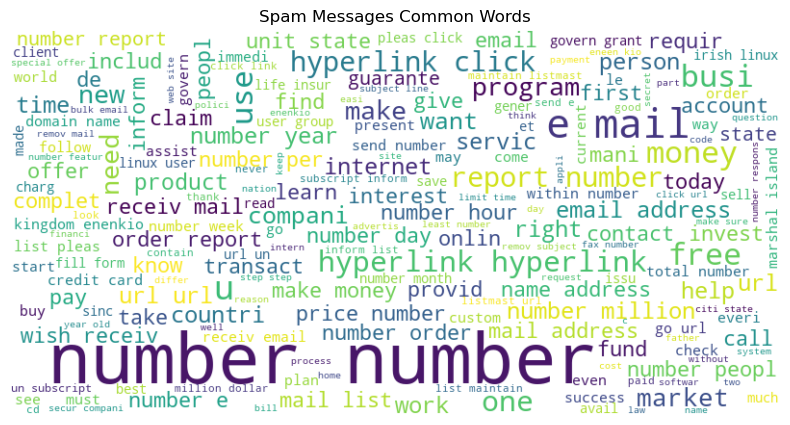

In [18]:
%pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

spam_words = " ".join(df[df['label'] == 1]['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(spam_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Spam Messages Common Words')
plt.show()